# Notebook 1: Exploratory Data Analysis of Revenue and Stream Raw Data

## How To Read This Notebook

This EDA notebook is intentionally practical:
- first, we profile both source tables to understand reliability risks,
- then we visualize temporal behavior by territory, DSP, and BU,
- finally we harmonize both sources to a common grain and verify missingness flags.

The goal is not only exploration, but to create confidence that the forecasting notebook starts from a defensible merged dataset.

### Summary of Data Harmonization

In plain language, the harmonization step answers one question:
"Can we place revenue and streams on the same coordinate system so nowcasting is fair?"

- Revenue is grouped by month, business unit, territory, and mapped DSP bucket (5 major DSP families + Other).
- Streams are grouped to the same monthly BU/territory/DSP grain, with non-matching countries rolled into `All Other Locations`.
- Both sources are aggregated with sums to remove raw-level fragmentation.
- The two tables are merged with an outer join so we keep both stream-only and revenue-only records.
- Missing and zero revenue are explicitly labeled (`is_na`, `is_zero`) to drive the downstream nowcast target definition.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
def profile_table(data: pd.DataFrame, table_name: str):
    """Print a compact quality snapshot so we can compare source tables quickly."""
    print(f"{table_name} shape: {data.shape}")
    print(f"Missing values by column:\n{data.isnull().sum()}")
    print(f"Duplicate rows: {data.duplicated().sum()}")


def plot_monthly_lines(
    data: pd.DataFrame,
    group_col: str,
    value_col: str,
    title: str,
    yscale: str = 'log',
):
    """Plot monthly totals by one grouping dimension for fast trend inspection."""
    monthly = (
        data.groupby(['month', group_col], dropna=False)[value_col]
        .sum()
        .reset_index()
        .sort_values('month')
    )

    plt.figure(figsize=(10, 4))
    for group_name, group_df in monthly.groupby(group_col):
        # Separate lines make trend breaks and volatility easier to spot by cohort.
        plt.plot(group_df['month'], group_df[value_col], label=group_name)

    plt.title(title)
    plt.xlabel('Month')
    plt.ylabel(value_col)
    if yscale:
        plt.yscale(yscale)
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.tight_layout()
    plt.show()

## 1. Explore Revenue Data

In [3]:
# Read the data
df_revenue = pd.read_excel("../data/Case Study Dataset.xlsx", sheet_name="Revenue")

df_revenue.info()

<class 'pandas.DataFrame'>
RangeIndex: 3534 entries, 0 to 3533
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   month               3534 non-null   datetime64[us]
 1   business_unit       3534 non-null   str           
 2   dsp                 3534 non-null   str           
 3   territory_name      3534 non-null   str           
 4   total_gross_amount  3525 non-null   float64       
dtypes: datetime64[us](1), float64(1), str(3)
memory usage: 138.2 KB


In [4]:
# Basic data-quality checks
profile_table(df_revenue, 'Revenue')

Revenue shape: (3534, 5)
Missing values by column:
month                 0
business_unit         0
dsp                   0
territory_name        0
total_gross_amount    9
dtype: int64
Duplicate rows: 0


In [5]:
# Investigate NA values
df_revenue[df_revenue["total_gross_amount"].isna()]


,month,business_unit,dsp,territory_name,total_gross_amount
26,2025-04-01,BU 3,Apple Music,France,NaN
417,2025-02-01,BU 3,Apple Music,Mexico,NaN
616,2025-04-01,BU 3,Apple Music,India,NaN
1033,2025-01-01,BU 3,Apple Music,Germany,NaN
1217,2025-02-01,BU 3,Apple Music,Germany,NaN
1356,2025-08-01,BU 3,Apple Music,Mexico,NaN
1897,2025-04-01,BU 3,Apple Music,Germany,NaN
2378,2025-07-01,BU 3,Apple Music,Brazil,NaN
2782,2025-03-01,BU 3,Apple Music,France,NaN


In [6]:
# Check levels of categorical variables
str_cols = df_revenue.select_dtypes(include="str").columns
for col in str_cols:
    print(f"{col}: {df_revenue[col].unique()}")

business_unit: <StringArray>
['BU 2', 'BU 3', 'BU 1', 'BU 4']
Length: 4, dtype: str
dsp: <StringArray>
[     'YouTube Premium Individual monthly',
                            'Apple/iTunes',
                    'Apple Music Dj Mixes',
                             'Apple Music',
                           'YouTube - Ads',
                                 'Spotify',
                       'YouTube - Premium',
                      'YouTube Ad Revenue',
                                  'Amazon',
          'YouTube Premium Family monthly',
                    'YouTube - Audio Tier',
                            'Amazon Prime',
                                 'YouTube',
         'YouTube Premium Student monthly',
                        'Amazon Unlimited',
            'YouTube Music Family monthly',
           'YouTube Music Student monthly',
                     'Amazon Ad Supported',
                                  'Tiktok',
                           'YouTube Music',
        'YouTube 

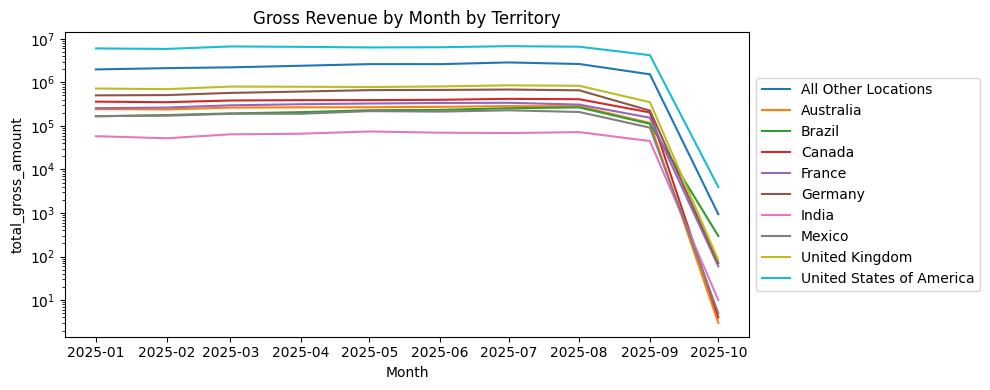

In [7]:
# Revenue by month and territory
plot_monthly_lines(
    data=df_revenue,
    group_col='territory_name',
    value_col='total_gross_amount',
    title='Gross Revenue by Month by Territory',
    yscale='log',
)

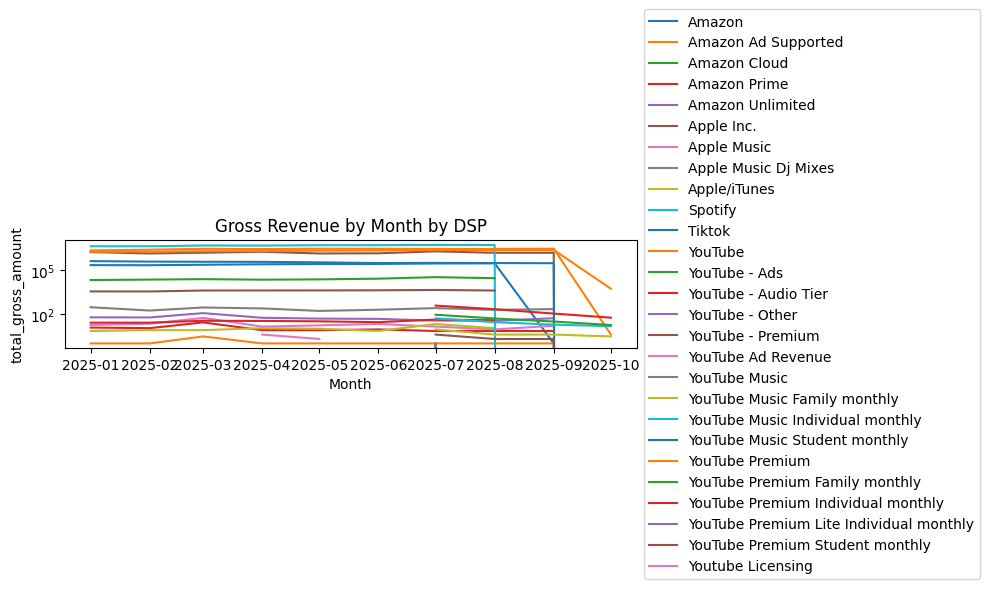

In [8]:
# Revenue by month and DSP
plot_monthly_lines(
    data=df_revenue,
    group_col='dsp',
    value_col='total_gross_amount',
    title='Gross Revenue by Month by DSP',
    yscale='log',
)

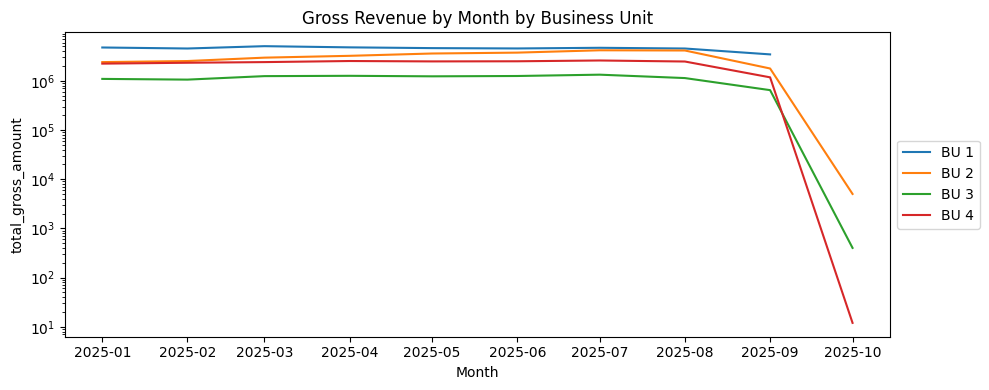

In [9]:
# Revenue by month and business unit
plot_monthly_lines(
    data=df_revenue,
    group_col='business_unit',
    value_col='total_gross_amount',
    title='Gross Revenue by Month by Business Unit',
    yscale='log',
)

### Summary

- There are many missing values or 0 values in the gross revenue data.
- The granularity of DSP does not match that of the stream data.
- Group by territory alone, the revenue seems to be a stationary process, whereas it is highly volatile with respect to DSP and BU.

## 2. Explore the Stream Data

In [10]:
df_stream = pd.read_excel("../data/Case Study Dataset.xlsx", sheet_name="Streams")

df_stream.info()

<class 'pandas.DataFrame'>
RangeIndex: 26036 entries, 0 to 26035
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   month          26036 non-null  datetime64[us]
 1   business_unit  26036 non-null  str           
 2   dsp            26036 non-null  str           
 3   country        26036 non-null  str           
 4   total_streams  26036 non-null  int64         
dtypes: datetime64[us](1), int64(1), str(3)
memory usage: 1017.2 KB


In [11]:
# Basic data-quality checks
profile_table(df_stream, 'Streams')

Streams shape: (26036, 5)
Missing values by column:
month            0
business_unit    0
dsp              0
country          0
total_streams    0
dtype: int64
Duplicate rows: 0


In [12]:
# Check unique values of categorical variables
str_cols = df_stream.select_dtypes(include="str").columns
for col in str_cols:
    print(f"{col}: {df_stream[col].unique()}")

business_unit: <StringArray>
['BU 2', 'BU 4', 'BU 3', 'BU 1']
Length: 4, dtype: str
dsp: <StringArray>
['TikTok', 'Spotify', 'Amazon', 'Apple', 'YouTube']
Length: 5, dtype: str
country: <StringArray>
[                                 'Norway',
                          'Western Sahara',
                                  'Brazil',
                                 'Czechia',
                              'Azerbaijan',
                                'Malaysia',
                                  'Turkey',
                           'Åland Islands',
                                   'Samoa',
                         'North Macedonia',
 ...
                    'Syrian Arab Republic',
                                  'Guinea',
          'British Indian Ocean Territory',
                             'Afghanistan',
                            'Cook Islands',
                     'All Other Locations',
    'United States Minor Outlying Islands',
 'Korea (Democratic People's Republic of)',
   

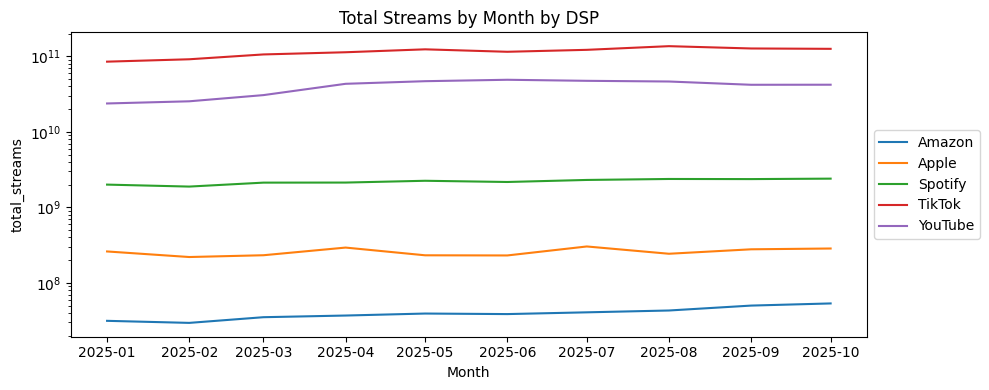

In [13]:
# Streams by month and DSP
plot_monthly_lines(
    data=df_stream,
    group_col='dsp',
    value_col='total_streams',
    title='Total Streams by Month by DSP',
    yscale='log',
)

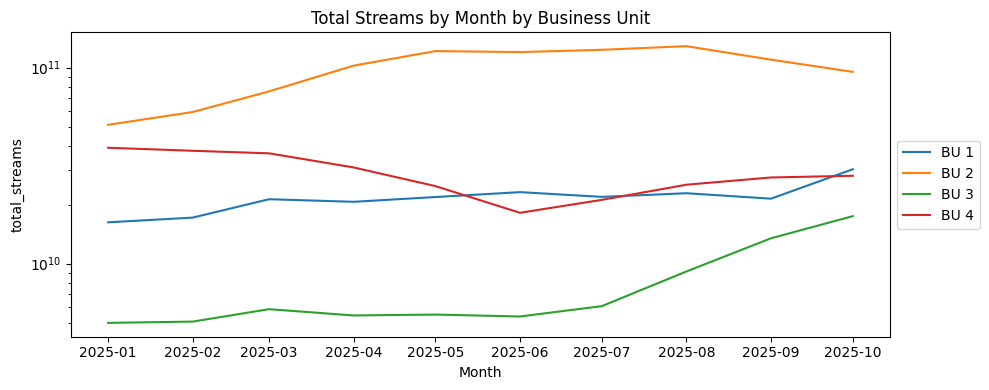

In [14]:
# Streams by month and business unit
plot_monthly_lines(
    data=df_stream,
    group_col='business_unit',
    value_col='total_streams',
    title='Total Streams by Month by Business Unit',
    yscale='log',
)

### Summary

- There are no missing or 0 values in streams, which verified our assumption (good).
- The granularity of country doesn't match that of territories in the revenue data.
- The streaming process also seems non-stationary with respect to BU.

## 3. Data Harmonization

I want the data to be harmonized with the follows:

1. For Revenue:
    - Group by BU, aggregate monthly revenue data into the 5 major DSP
2. For Streams:
    - Group by BU, aggregate monthly streams data into the major territories
3. Merge the two datasets, label NA and zero values with an indicator

In [15]:
# Extract unique values of dsp and territory_name for later use
lst_dsp = df_stream['dsp'].unique().tolist()
lst_territory = df_revenue['territory_name'].unique().tolist()

print(lst_dsp)
print(lst_territory)

['TikTok', 'Spotify', 'Amazon', 'Apple', 'YouTube']
['Brazil', 'Canada', 'United States of America', 'Germany', 'United Kingdom', 'All Other Locations', 'France', 'India', 'Australia', 'Mexico']


In [16]:
# Hardcode mapping patterns
dsp_map = {
    'YouTube': [
        'YouTube Premium Individual monthly',
        'YouTube - Ads',
        'YouTube - Premium',
        'YouTube Ad Revenue',
        'YouTube Premium Family monthly',
        'YouTube - Audio Tier',
        'YouTube',
        'YouTube Premium Student monthly',
        'YouTube Music Family monthly',
        'YouTube Music Student monthly',
        'YouTube Music',
        'YouTube Music Individual monthly',
        'YouTube Premium Lite Individual monthly',
        'Youtube Licensing',
        'YouTube Premium',
        'YouTube - Other'
    ],
    'TikTok': ['Tiktok'],
    'Spotify': ['Spotify'],
    'Amazon': ['Amazon', 
               'Amazon Prime', 
               'Amazon Unlimited', 
               'Amazon Ad Supported',
               'Amazon Cloud'],
    'Apple': ['Apple/iTunes',
              'Apple Music Dj Mixes',
              'Apple Music',
              'Apple Inc.']
}

In [17]:
df_revenue_agg = df_revenue.copy()

# Apply the mapping to create a new column
df_revenue_agg['dsp_pattern'] = df_revenue_agg['dsp'].apply(lambda x: next((dsp for dsp, 
                                                                            patterns in dsp_map.items() if x in patterns), 
                                                                           'Other'))
df_revenue_agg = df_revenue_agg.groupby(['month', 'business_unit','territory_name','dsp_pattern'])['total_gross_amount'].sum().reset_index()

# rename dsp_pattern to dsp
df_revenue_agg.rename(columns={'dsp_pattern': 'dsp'}, inplace=True)

df_revenue_agg['dsp'].unique()

<StringArray>
['Amazon', 'Apple', 'Spotify', 'TikTok', 'YouTube']
Length: 5, dtype: str

In [18]:
df_revenue_agg.info()

<class 'pandas.DataFrame'>
RangeIndex: 1812 entries, 0 to 1811
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   month               1812 non-null   datetime64[us]
 1   business_unit       1812 non-null   str           
 2   territory_name      1812 non-null   str           
 3   dsp                 1812 non-null   str           
 4   total_gross_amount  1812 non-null   float64       
dtypes: datetime64[us](1), float64(1), str(3)
memory usage: 70.9 KB


In [19]:
df_stream_agg = df_stream.copy()

df_stream_agg['territory_name'] = df_stream_agg['country'].apply(lambda x: x if x in lst_territory else 'All Other Locations')

df_stream_agg = df_stream_agg.groupby(['month', 'business_unit','territory_name','dsp'])['total_streams'].sum().reset_index()

df_stream_agg['territory_name'].unique()

<StringArray>
[     'All Other Locations',                'Australia',
                   'Brazil',                   'Canada',
                   'France',                  'Germany',
                    'India',                   'Mexico',
           'United Kingdom', 'United States of America']
Length: 10, dtype: str

In [20]:
df_stream_agg.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   month           2000 non-null   datetime64[us]
 1   business_unit   2000 non-null   str           
 2   territory_name  2000 non-null   str           
 3   dsp             2000 non-null   str           
 4   total_streams   2000 non-null   int64         
dtypes: datetime64[us](1), int64(1), str(3)
memory usage: 78.3 KB


In [21]:
# Merge the two datasets on month, business_unit, territory_name, and dsp
df_merged = pd.merge(df_stream_agg, df_revenue_agg, on=['month', 'business_unit', 'territory_name', 'dsp'], how='outer')

df_merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   month               2000 non-null   datetime64[us]
 1   business_unit       2000 non-null   str           
 2   territory_name      2000 non-null   str           
 3   dsp                 2000 non-null   str           
 4   total_streams       2000 non-null   int64         
 5   total_gross_amount  1812 non-null   float64       
dtypes: datetime64[us](1), float64(1), int64(1), str(3)
memory usage: 93.9 KB


In [22]:
# label 0 or na values in the merged dataset
df_merged['is_na'] = df_merged['total_gross_amount'].isna().astype(int)
df_merged['is_zero'] = (df_merged['total_gross_amount'] == 0).astype(int)

# Print the amount of NA and zero values
print(f"Number of NA values: {df_merged['is_na'].sum()}")
print(f"Number of zero values: {df_merged['is_zero'].sum()}")

Number of NA values: 188
Number of zero values: 98


In [23]:
df_merged.to_csv("../data/merged_data.csv", index=False)

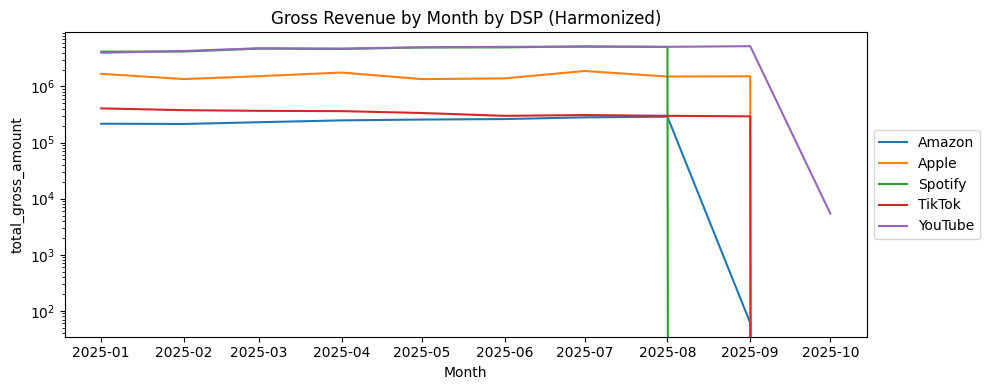

In [24]:
# Harmonized revenue by month and DSP
plot_monthly_lines(
    data=df_merged,
    group_col='dsp',
    value_col='total_gross_amount',
    title='Gross Revenue by Month by DSP (Harmonized)',
    yscale='log',
)

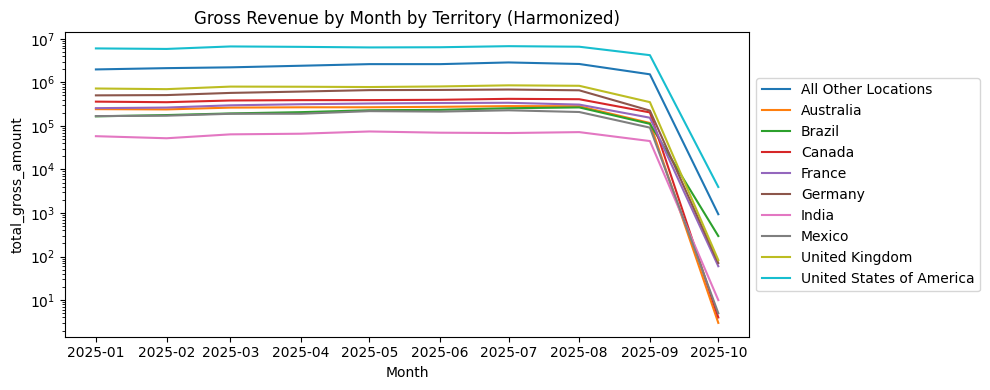

In [25]:
# Harmonized revenue by month and territory
plot_monthly_lines(
    data=df_merged,
    group_col='territory_name',
    value_col='total_gross_amount',
    title='Gross Revenue by Month by Territory (Harmonized)',
    yscale='log',
)

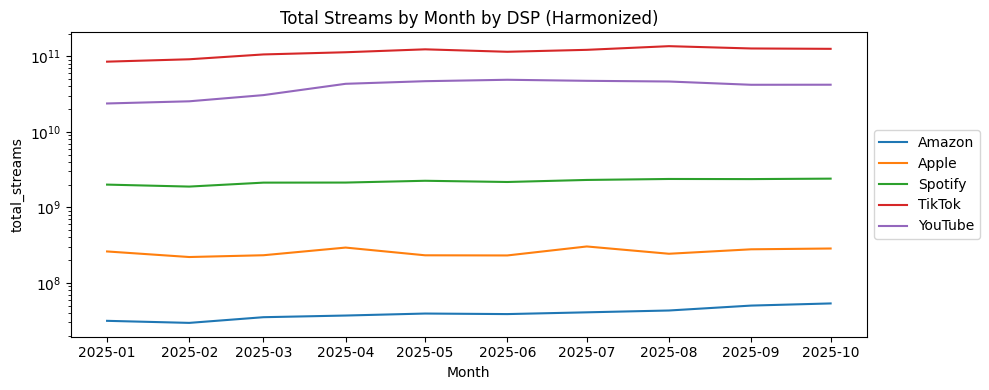

In [26]:
# Harmonized streams by month and DSP
plot_monthly_lines(
    data=df_merged,
    group_col='dsp',
    value_col='total_streams',
    title='Total Streams by Month by DSP (Harmonized)',
    yscale='log',
)

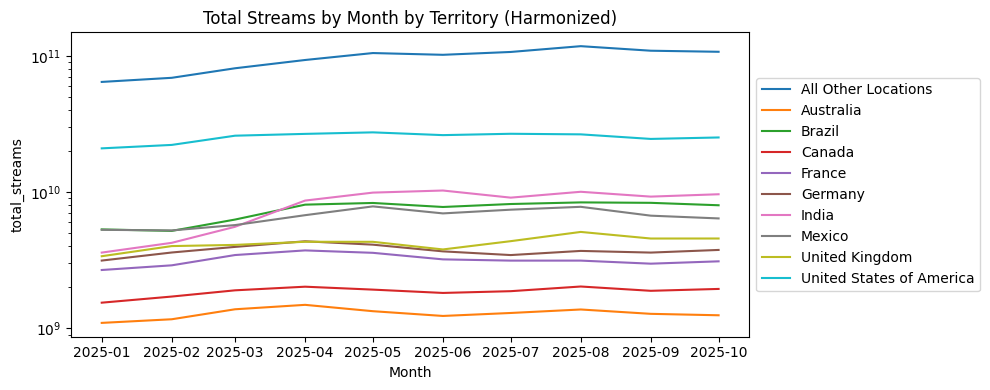

In [27]:
# Harmonized streams by month and territory
plot_monthly_lines(
    data=df_merged,
    group_col='territory_name',
    value_col='total_streams',
    title='Total Streams by Month by Territory (Harmonized)',
    yscale='log',
)